# E_commarce customer segmentation system

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Step 1 ( Data Preprocessing )

In [3]:
df["Income"]=df["Income"].fillna(df["Income"].median())


# Feature Engineering

In [4]:
# Customer Age
df["Age"]=2026-df["Year_Birth"]


In [16]:
# Customer Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer Tenure Days"]=(reference_date-df["Dt_Customer"]).dt.days


In [6]:
# Spending
df["Total Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
# Total Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [14]:
# Education
df["Education"]=df["Education"].replace({
    "2n Cycle":"Undergraduate","Basic":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
})


In [15]:
# Maritial Status
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})


In [20]:
 df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer Tenure Days', 'Total Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [29]:
# Dropping Unwanted columns
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntGoldProds","MntSweetProducts"]
col_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=col_to_drop)


# Remove Outliers

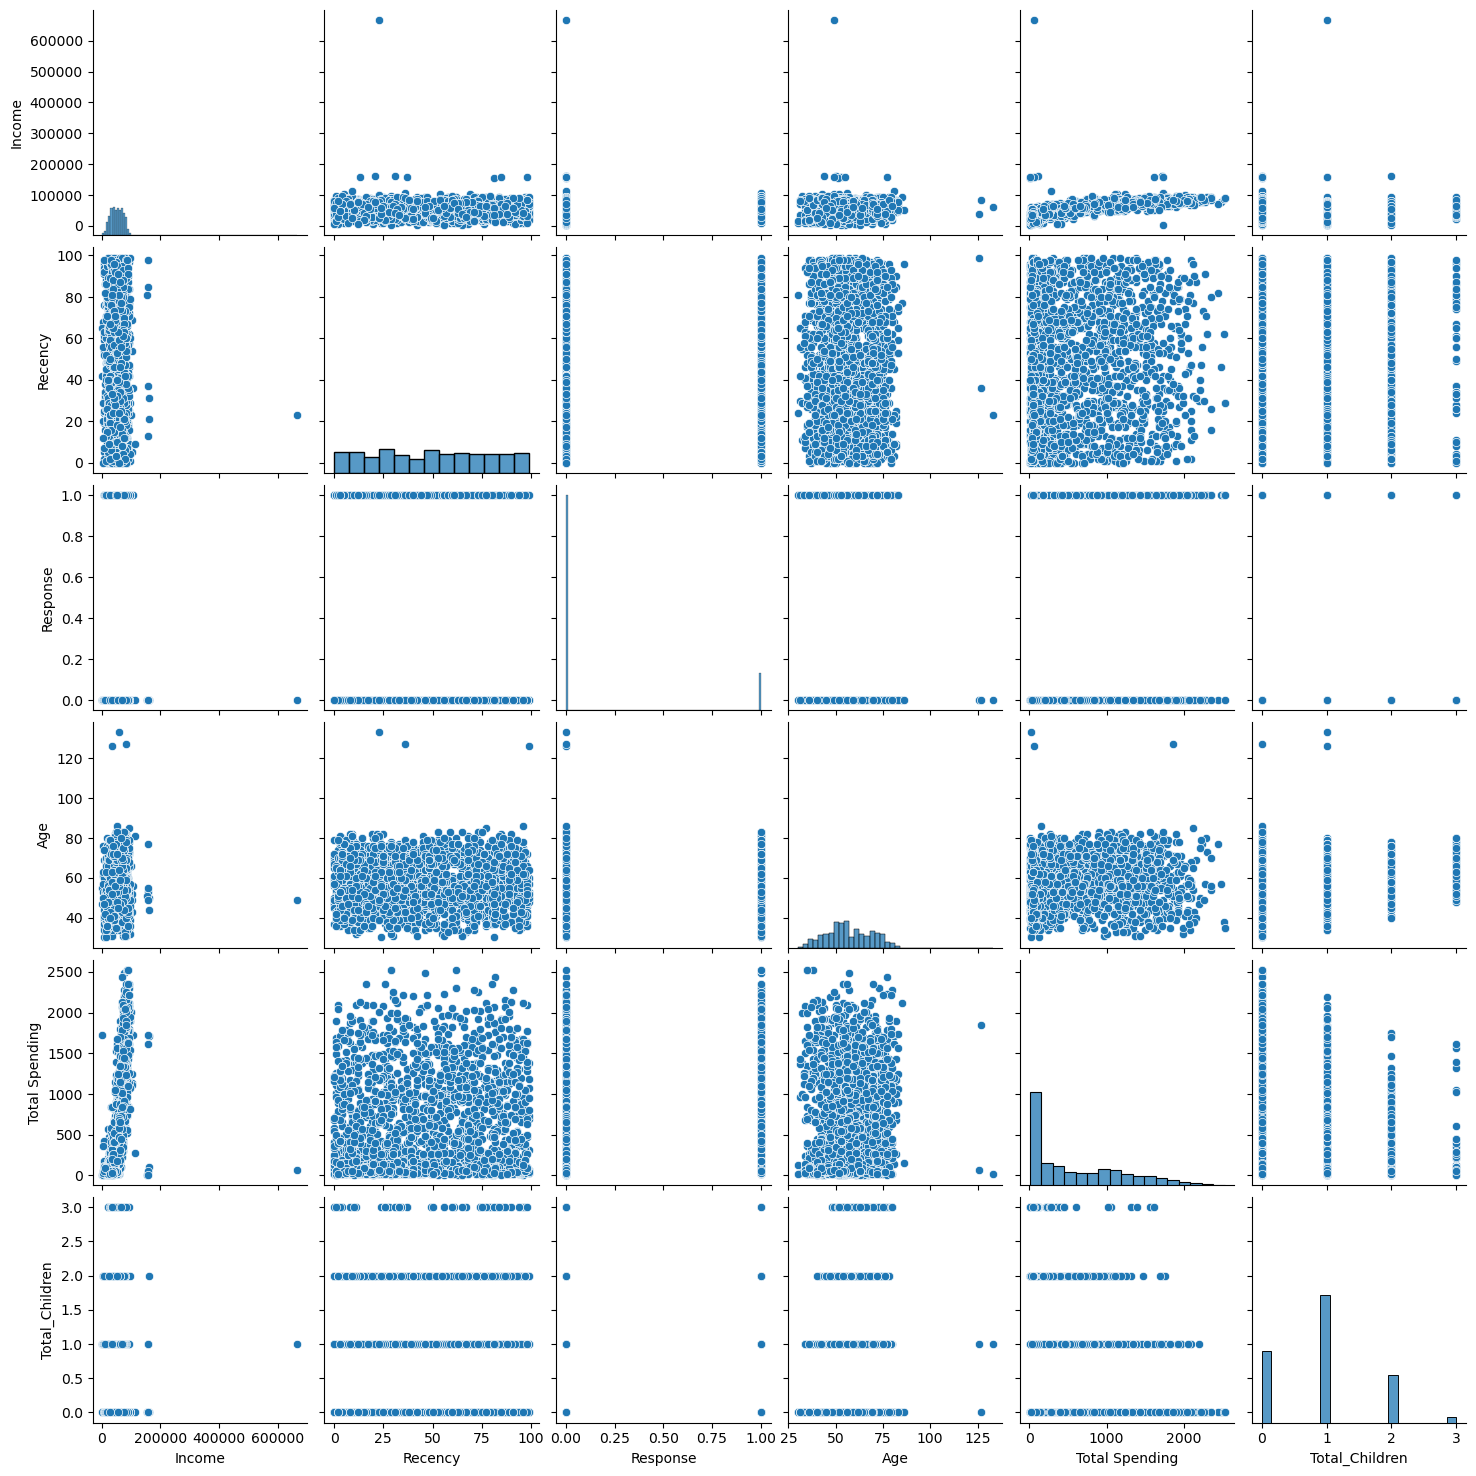

In [28]:
# create a relative pair plots of some features
# pair plot wo plot hota hai jab ha ek features ke 
# saath multiiple feature ke plot create krte hai
cols=["Income","Recency","Response","Age","Total Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [33]:
# Removing Outliers
print(df.s)
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
df_cleaned.shape

         ID  Year_Birth     Education Marital_Status   Income  Kidhome  \
0      5524        1957      Graduate         Single  58138.0        0   
1      2174        1954      Graduate         Single  46344.0        1   
2      4141        1965      Graduate       Together  71613.0        0   
3      6182        1984      Graduate       Together  26646.0        1   
4      5324        1981  Postgraduate        Married  58293.0        1   
...     ...         ...           ...            ...      ...      ...   
2235  10870        1967      Graduate        Married  61223.0        0   
2236   4001        1946  Postgraduate       Together  64014.0        2   
2237   7270        1981      Graduate       Divorced  56981.0        0   
2238   8235        1956  Postgraduate       Together  69245.0        0   
2239   9405        1954  Postgraduate        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumCatalogPurchases  \
0            0  2012-09-04       58 

(2236, 15)